# Treinamento e comparação de modelos sobre a ABT

Este notebook compara três classificadores para prever `target` a partir de `DataPipeline/abt.csv`: regressão logística, árvore de decisão e random forest. O pré-processamento é aprendido somente com os dados de treino e fica incorporado ao artefato final.

In [1]:
import importlib.util
import subprocess
import sys
from pathlib import Path

required_modules = ["matplotlib", "numpy", "pandas", "sklearn"]
missing_modules = [module for module in required_modules if importlib.util.find_spec(module) is None]

print(f"Python/kernel em uso: {sys.executable}")

if missing_modules:
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    requirements_path = next(
        (path / "requirements.txt" for path in candidates if (path / "requirements.txt").is_file()),
        None,
    )
    if requirements_path is None:
        raise FileNotFoundError("requirements.txt não encontrado. Execute o notebook a partir de data-platform ou da raiz do projeto.")

    print(f"Instalando dependências ausentes no kernel atual: {missing_modules}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(requirements_path)])
else:
    print("Dependências principais já disponíveis no kernel atual.")

Python/kernel em uso: /opt/conda/bin/python
Dependências principais já disponíveis no kernel atual.


In [2]:
import pickle
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
TEST_SIZE = 0.20
DECISION_THRESHOLD = 0.50
CV_FOLDS = 5

## 1. Carregamento da ABT

A busca funciona ao executar o notebook pela pasta `Model`, por `data-platform` ou pela raiz do repositório.

In [3]:
project_root = Path.home() / ""
csv_candidates = [
    # project_root / "data-platform/DataPipeline/abt.csv",
    project_root / "work/abt.csv",
    Path("../DataPipeline/abt.csv"),
    Path("DataPipeline/abt.csv"),
    Path("data-platform/DataPipeline/abt.csv"),
    Path("data-platform/DataPipeline/abt.csv"),
    Path("home/jovyan/work/abt.csv"),
]

ABT_PATH = None
searched = []
for path in csv_candidates:
    try:
        candidate = path if path.is_absolute() else path.absolute()
        searched.append(str(candidate))
        if candidate.is_file():
            ABT_PATH = candidate
            break
    except OSError as error:
        searched.append(f"{path} (indisponível: {error})")

if ABT_PATH is None:
    raise FileNotFoundError("abt.csv não encontrado. Caminhos pesquisados:\n" + "\n".join(searched))

df = pd.read_csv(ABT_PATH, encoding="utf-8")
print(f"Arquivo: {ABT_PATH}")
print(f"ABT carregada: {df.shape[0]:,} linhas e {df.shape[1]} colunas")
display(df.head())

Arquivo: /home/jovyan/work/abt.csv
ABT carregada: 307,511 linhas e 45 colunas


,sk_id_curr,target,ext_source_2,ext_source_mean,ext_source_1,ext_source_3,region_rating_client_w_city,days_last_phone_change,days_id_publish,days_registration,...,bureau_last_days_credit,bureau_active_rate,bureau_active_count,bureau_closed_rate,bureau_debt_credit_ratio,bureau_overdue_count,inst_late_payment_rate,inst_underpayment_rate,has_bureau,has_installments_history
0,100002,1,0.262949,0.161787,0.083037,0.139376,2,-1134.0,-2120,-3648.0,...,-103.0,0.25,2.0,0.75,0.284122,0.0,0.000000,0.000000,1,1
1,100003,0,0.622246,0.466757,0.311267,0.535276,1,-828.0,-291,-1186.0,...,-606.0,0.25,1.0,0.75,0.000000,0.0,0.000000,0.000000,1,1
2,100004,0,0.555912,0.642739,0.505998,0.729567,2,-815.0,-2531,-4260.0,...,-408.0,0.00,0.0,1.00,0.000000,0.0,0.000000,0.000000,1,1
3,100006,0,0.650442,0.650442,0.505998,0.535276,2,-617.0,-2437,-9833.0,...,0.0,0.00,0.0,0.00,0.000000,0.0,0.000000,0.000000,0,1
4,100007,0,0.322738,0.322738,0.505998,0.535276,2,-1106.0,-3458,-4311.0,...,-1149.0,0.00,0.0,1.00,0.000000,0.0,0.242424,0.090909,1,1


## 2. Preparação das variáveis

O identificador `sk_id_curr` não participa do treinamento. Valores infinitos são tratados como ausentes e imputados dentro do pipeline.

In [4]:
required_columns = {"sk_id_curr", "target"}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Colunas obrigatórias ausentes na ABT: {sorted(missing_columns)}")

df_model = df.replace([np.inf, -np.inf], np.nan).copy()
X = df_model.drop(columns=["target", "sk_id_curr"])
y = pd.to_numeric(df_model["target"], errors="raise").astype(int)

empty_columns = X.columns[X.isna().all()].tolist()
X = X.drop(columns=empty_columns)

print(f"Variáveis explicativas: {X.shape[1]}")
print(f"Colunas totalmente vazias removidas: {empty_columns}")
print("Distribuição do target (%):")
display(y.value_counts(normalize=True).mul(100).round(2).sort_index())

Variáveis explicativas: 43
Colunas totalmente vazias removidas: []
Distribuição do target (%):


target
0    91.93
1     8.07
Name: proportion, dtype: float64

## 3. Separação entre treino e teste

A estratificação mantém aproximadamente a mesma proporção de inadimplentes nos dois conjuntos.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

# numeric_features = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
# categorical_features = X_train.select_dtypes(exclude=["number", "bool"]).columns.tolist()
candidate_binary_features = [
    "has_prev_app",
    "days_employed_anom",
    "has_installments_history",
    "has_bureau",
    "has_car",
]

binary_features = [
    col for col in candidate_binary_features
    if col in X_train.columns
]

numeric_features = [
    col for col in X_train.select_dtypes(include=["number"]).columns
    if col not in binary_features
]

categorical_features = [
    col for col in X_train.columns
    if col not in numeric_features
    and col not in binary_features
]
print(f"Treino: {len(X_train):,} | Teste: {len(X_test):,}")
# print(f"Numéricas: {len(numeric_features)} | Categóricas: {len(categorical_features)}")
print(f"Numéricas contínuas: {len(numeric_features)}")
print(numeric_features)

print(f"\nBinárias/flags: {len(binary_features)}")
print(binary_features)

print(f"\nCategóricas: {len(categorical_features)}")
print(categorical_features)

Treino: 246,008 | Teste: 61,503
Numéricas contínuas: 33
['ext_source_2', 'ext_source_mean', 'ext_source_1', 'ext_source_3', 'region_rating_client_w_city', 'days_last_phone_change', 'days_id_publish', 'days_registration', 'reg_city_not_work_city', 'reg_city_not_live_city', 'live_city_not_work_city', 'own_car_age', 'def_60_cnt_social_circle', 'amt_req_credit_bureau_year', 'cnt_children', 'cnt_fam_members', 'amt_income_total', 'amt_credit', 'amt_annuity', 'age', 'years_employed', 'fe_credit_income_percent', 'fe_annuity_income_percent', 'prev_refused_rate', 'bureau_avg_days_credit', 'bureau_last_days_credit', 'bureau_active_rate', 'bureau_active_count', 'bureau_closed_rate', 'bureau_debt_credit_ratio', 'bureau_overdue_count', 'inst_late_payment_rate', 'inst_underpayment_rate']

Binárias/flags: 5
['has_prev_app', 'days_employed_anom', 'has_installments_history', 'has_bureau', 'has_car']

Categóricas: 5
['occupation_type', 'organization_type', 'name_income_type', 'name_education_type', 'code

## 4. Pré-processamento e comparação de modelos

Medianas, escalas e categorias são aprendidas somente dentro de cada partição de treino da validação cruzada. A comparação usa o mesmo split, o mesmo pré-processamento e as mesmas métricas para os três modelos. A métrica principal de seleção é ROC AUC, pois a base é desbalanceada e o objetivo é ordenar clientes por risco.

In [6]:
# numeric_pipeline = Pipeline([
#     ("imputer", SimpleImputer(strategy="median")),
#     ("scaler", StandardScaler()),
# ])

# categorical_pipeline = Pipeline([
#     ("imputer", SimpleImputer(strategy="most_frequent")),
#     ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20)),
# ])

# preprocessor = ColumnTransformer([
#     ("numeric", numeric_pipeline, numeric_features),
#     ("categorical", categorical_pipeline, categorical_features),
# ])

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

binary_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20)),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20)),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("binary", binary_pipeline, binary_features),
    ("categorical", categorical_pipeline, categorical_features),
])
cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

candidate_models = {
    "logistic_regression": LogisticRegression(
        class_weight="balanced",
        max_iter=100,
        solver="newton-cholesky",
        random_state=RANDOM_STATE,
    ),
    "decision_tree": DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=100,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=100,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

results = []
fitted_models = {}

for model_name, classifier in candidate_models.items():
    estimator = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", classifier),
    ])
    started_at = time.perf_counter()
    cv_scores = cross_val_score(estimator, X_train, y_train, scoring="roc_auc", cv=cv, n_jobs=-1)
    estimator.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - started_at

    y_probability_model = estimator.predict_proba(X_test)[:, 1]
    y_prediction_model = (y_probability_model >= DECISION_THRESHOLD).astype(int)

    results.append({
        "model": model_name,
        "roc_auc": roc_auc_score(y_test, y_probability_model),
        "accuracy": accuracy_score(y_test, y_prediction_model),
        "precision": precision_score(y_test, y_prediction_model, zero_division=0),
        "average_precision": average_precision_score(y_test, y_probability_model),
        "cv_roc_auc_mean": cv_scores.mean(),
        "cv_roc_auc_std": cv_scores.std(),
        "fit_seconds": round(fit_seconds, 2),
    })
    fitted_models[model_name] = estimator

comparison = pd.DataFrame(results).sort_values(["roc_auc", "precision", "accuracy"], ascending=False)
best_model_name = comparison.iloc[0]["model"]
model = fitted_models[best_model_name]

print(f"Melhor modelo pela ROC AUC: {best_model_name}")
display(comparison.round(4))

Melhor modelo pela ROC AUC: logistic_regression


,model,roc_auc,accuracy,precision,average_precision,cv_roc_auc_mean,cv_roc_auc_std,fit_seconds
0,logistic_regression,0.7538,0.6957,0.1650,0.2382,0.7527,0.0012,22.04
2,random_forest,0.7488,0.7021,0.1660,0.2295,0.7463,0.0019,138.58
1,decision_tree,0.7262,0.6874,0.1555,0.1983,0.7234,0.0017,24.72


## 5. Avaliação do melhor modelo

ROC AUC mede a capacidade geral de ordenação. Accuracy e precision entram na comparação, mas ROC AUC é priorizada porque a base é desbalanceada.

Modelo selecionado: logistic_regression
ROC AUC: 0.7538 | Accuracy: 0.6957 | Precision: 0.1650 | Average Precision: 0.2382

Relatório de classificação (limiar = 0.50):
              precision    recall  f1-score   support

           0     0.9614    0.6969    0.8081     56538
           1     0.1650    0.6818    0.2656      4965

    accuracy                         0.6957     61503
   macro avg     0.5632    0.6893    0.5369     61503
weighted avg     0.8971    0.6957    0.7643     61503



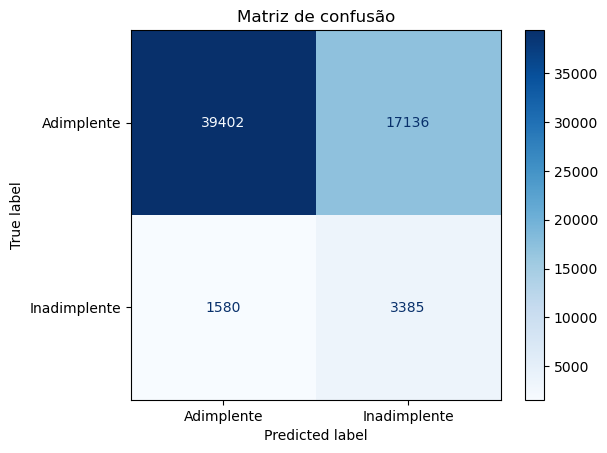

In [7]:
y_probability = model.predict_proba(X_test)[:, 1]
y_prediction = (y_probability >= DECISION_THRESHOLD).astype(int)

roc_auc = roc_auc_score(y_test, y_probability)
accuracy = accuracy_score(y_test, y_prediction)
precision_model = precision_score(y_test, y_prediction, zero_division=0)
average_precision = average_precision_score(y_test, y_probability)

print(f"Modelo selecionado: {best_model_name}")
print(f"ROC AUC: {roc_auc:.4f} | Accuracy: {accuracy:.4f} | Precision: {precision_model:.4f} | Average Precision: {average_precision:.4f}")
print(f"\nRelatório de classificação (limiar = {DECISION_THRESHOLD:.2f}):")
print(classification_report(y_test, y_prediction, digits=4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_prediction,
    display_labels=["Adimplente", "Inadimplente"],
    cmap="Blues",
)
plt.title("Matriz de confusão")
plt.show()

In [8]:
# fpr, tpr, _ = roc_curve(y_test, y_probability)
# precision, recall, _ = precision_recall_curve(y_test, y_probability)

# fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# axes[0].plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
# axes[0].plot([0, 1], [0, 1], "--", color="gray")
# axes[0].set(title="Curva ROC", xlabel="Taxa de falsos positivos", ylabel="Taxa de verdadeiros positivos")
# axes[0].legend()

# axes[1].plot(recall, precision, label=f"AP = {average_precision:.3f}")
# axes[1].axhline(y_test.mean(), linestyle="--", color="gray", label="Modelo aleatório")
# axes[1].set(title="Curva Precision-Recall", xlabel="Recall", ylabel="Precisão")
# axes[1].legend()
# plt.tight_layout()
# plt.show()

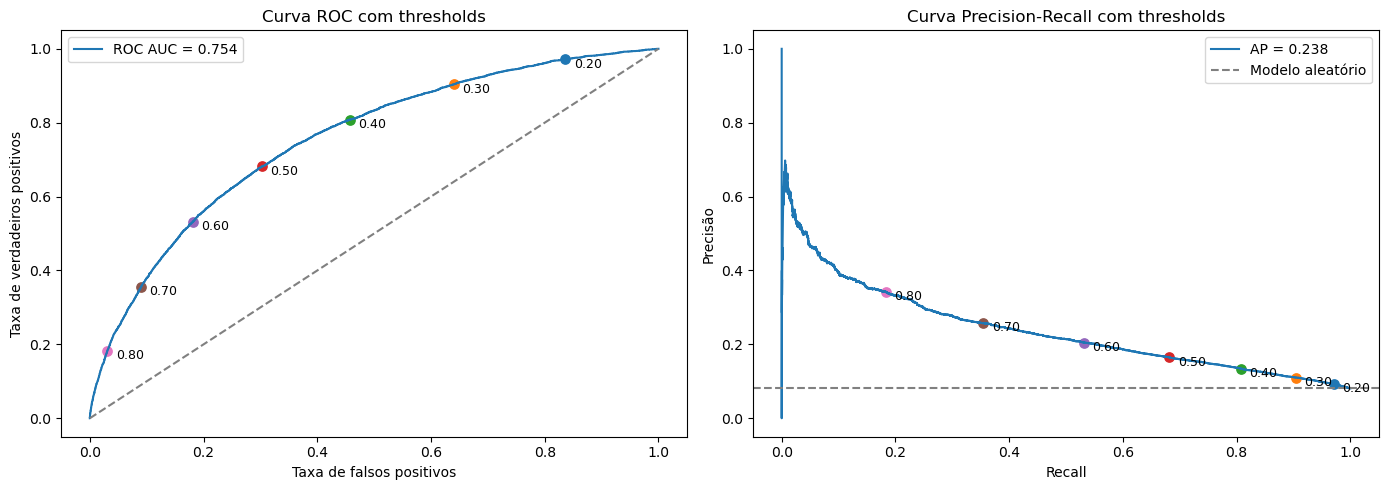

In [9]:
from sklearn.metrics import roc_curve, precision_recall_curve

fpr, tpr, roc_thresholds = roc_curve(y_test, y_probability)
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_probability)

threshold_marks = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")

for threshold in threshold_marks:
    idx = np.argmin(np.abs(roc_thresholds - threshold))
    axes[0].scatter(fpr[idx], tpr[idx], s=45)
    axes[0].annotate(
        f"{threshold:.2f}",
        (fpr[idx], tpr[idx]),
        textcoords="offset points",
        xytext=(6, -6),
        fontsize=9,
    )

axes[0].set(
    title="Curva ROC com thresholds",
    xlabel="Taxa de falsos positivos",
    ylabel="Taxa de verdadeiros positivos",
)
axes[0].legend()

axes[1].plot(recall, precision, label=f"AP = {average_precision:.3f}")
axes[1].axhline(y_test.mean(), linestyle="--", color="gray", label="Modelo aleatório")

for threshold in threshold_marks:
    idx = np.argmin(np.abs(pr_thresholds - threshold))
    axes[1].scatter(recall[idx], precision[idx], s=45)
    axes[1].annotate(
        f"{threshold:.2f}",
        (recall[idx], precision[idx]),
        textcoords="offset points",
        xytext=(6, -6),
        fontsize=9,
    )

axes[1].set(
    title="Curva Precision-Recall com thresholds",
    xlabel="Recall",
    ylabel="Precisão",
)
axes[1].legend()

plt.tight_layout()
plt.show()

In [10]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score

lucro_por_adimplente = 1000
prejuizo_por_inadimplente = 5000

thresholds = np.arange(0.10, 0.91, 0.01)
results = []

for threshold in thresholds:
    y_pred = (y_probability >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    lucro = (
        tn * lucro_por_adimplente
        - fp * lucro_por_adimplente
        - fn * prejuizo_por_inadimplente
        + tp * prejuizo_por_inadimplente
    )

    results.append({
        "threshold": threshold,
        "tn_adimplente_aprovado": tn,
        "fp_adimplente_rejeitado": fp,
        "fn_inadimplente_aprovado": fn,
        "tp_inadimplente_rejeitado": tp,
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred),
        "lucro_estimado": lucro,
    })

df_thresholds = pd.DataFrame(results)

In [11]:
df_thresholds.sort_values("lucro_estimado", ascending=False).head(20)

,threshold,tn_adimplente_aprovado,fp_adimplente_rejeitado,fn_inadimplente_aprovado,tp_inadimplente_rejeitado,precision,recall,lucro_estimado
58,0.68,50590,5948,3019,1946,0.246516,0.391944,39277000
59,0.69,51027,5511,3110,1855,0.251833,0.373615,39241000
57,0.67,50124,6414,2933,2032,0.240587,0.409265,39205000
60,0.70,51457,5081,3203,1762,0.257489,0.354884,39171000
56,0.66,49614,6924,2848,2117,0.234156,0.426385,39035000
61,0.71,51840,4698,3299,1666,0.261785,0.335549,38977000
55,0.65,49106,7432,2758,2207,0.228966,0.444512,38919000
63,0.73,52643,3895,3474,1491,0.276829,0.300302,38833000
62,0.72,52249,4289,3401,1564,0.267213,0.315005,38775000
54,0.64,48553,7985,2673,2292,0.223022,0.461631,38663000


In [12]:
thresholds = [0.40, 0.50, 0.60, 0.70]

for threshold in thresholds:
    y_pred = (y_probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    print(f"\nThreshold: {threshold:.2f}")
    print(f"TN - adimplente aprovado:      {tn}")
    print(f"FP - adimplente rejeitado:     {fp}")
    print(f"FN - inadimplente aprovado:    {fn}")
    print(f"TP - inadimplente rejeitado:   {tp}")
    print(classification_report(y_test, y_pred, digits=4))


Threshold: 0.40
TN - adimplente aprovado:      30703
FP - adimplente rejeitado:     25835
FN - inadimplente aprovado:    953
TP - inadimplente rejeitado:   4012
              precision    recall  f1-score   support

           0     0.9699    0.5431    0.6963     56538
           1     0.1344    0.8081    0.2305      4965

    accuracy                         0.5644     61503
   macro avg     0.5522    0.6756    0.4634     61503
weighted avg     0.9024    0.5644    0.6587     61503


Threshold: 0.50
TN - adimplente aprovado:      39402
FP - adimplente rejeitado:     17136
FN - inadimplente aprovado:    1580
TP - inadimplente rejeitado:   3385
              precision    recall  f1-score   support

           0     0.9614    0.6969    0.8081     56538
           1     0.1650    0.6818    0.2656      4965

    accuracy                         0.6957     61503
   macro avg     0.5632    0.6893    0.5369     61503
weighted avg     0.8971    0.6957    0.7643     61503


Threshold: 0.60
TN -

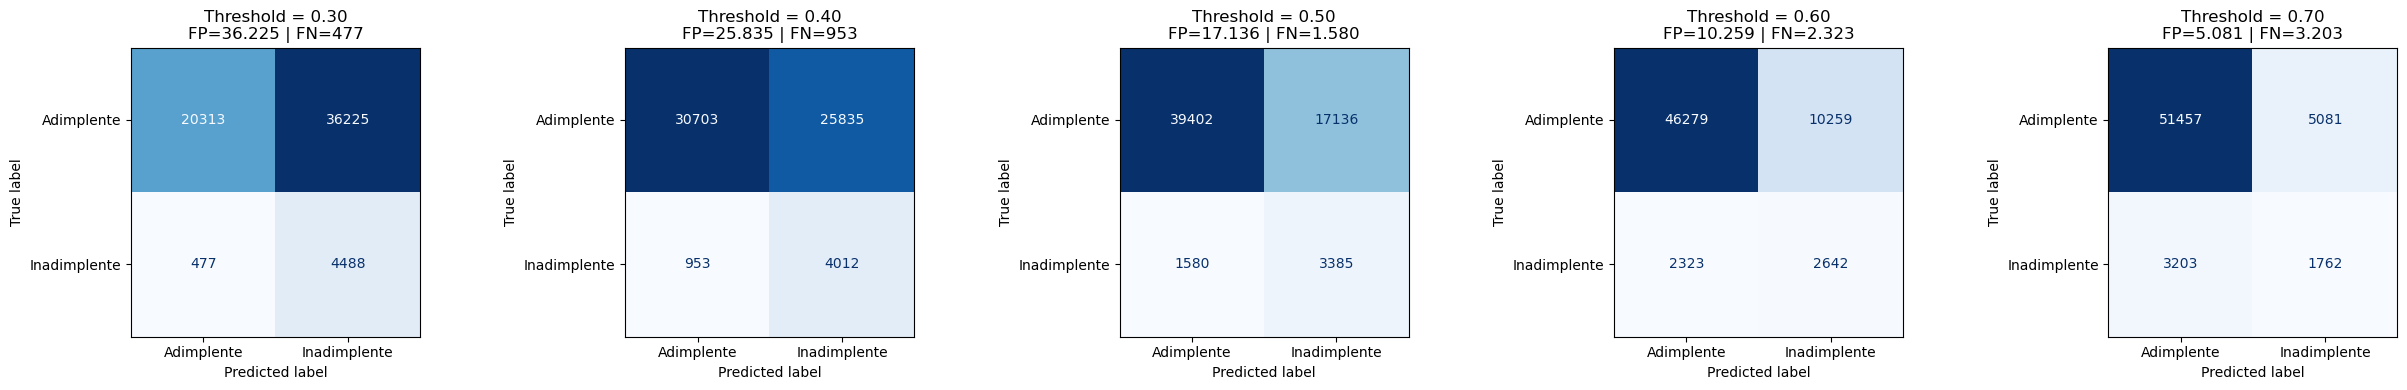

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

fig, axes = plt.subplots(1, len(thresholds), figsize=(5 * len(thresholds), 4))

if len(thresholds) == 1:
    axes = [axes]

for ax, threshold in zip(axes, thresholds):
    y_pred = (y_probability >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Adimplente", "Inadimplente"]
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
        colorbar=False
    )

    tn, fp, fn, tp = cm.ravel()

    ax.set_title(
        f"Threshold = {threshold:.2f}\n"
        f"FP={fp:,} | FN={fn:,}".replace(",", ".")
    )

plt.tight_layout()
plt.show()

Em termos de negócio:  
0.30 é muito defensivo: evita muito calote, mas sacrifica vendas demais.  
0.70 preserva vendas, mas deixa passar inadimplente demais.  
0.50 está no meio, mas ainda rejeita 17.136 bons clientes.  
0.60 parece um candidato interessante: reduz bastante os falsos positivos em relação ao 0.50, de 17.136 para 10.259, mas perde 742 inadimplentes capturados.  
0.40 é o inverso: captura mais inadimplentes que 0.50, mas rejeita mais 8.699 bons clientes.

Pergunta chave: o lucro de aprovar 6.877 clientes bons a mais compensa o prejuízo de deixar passar 742 inadimplentes a mais?  
Podemos escolher 0.60 se: lucro_por_cliente_bom multiplicado por 6.877 > prejuizo_por_inadimplente multiplicado por 742.  
Do contrário podemos escolher 0.50.

## Análise de sensibilidade ao desbalanceamento

Nesta seção, comparamos a regressão logística selecionada com e sem `class_weight="balanced"`, mantendo o mesmo split, o mesmo pré-processamento e a mesma grade de hiperparâmetros. O objetivo é avaliar o efeito do balanceamento sobre ROC AUC, Average Precision, Precision, Recall e matriz de confusão.

In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.base import clone
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

balance_experiments = {
    "sem_balanceamento": None,
    "com_balanceamento": "balanced",
}

balance_results = []
balance_models = {}
balance_probabilities = {}

for experiment_name, class_weight in balance_experiments.items():
    estimator = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            solver="newton-cholesky",
            max_iter=100,
            random_state=42,
            class_weight=class_weight,
        )),
    ])

    param_grid_balance = {
        "classifier__C": [0.01, 0.1, 1.0, 10.0, 100.0],
    }

    grid_balance = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid_balance,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=True,
    )

    grid_balance.fit(X_train, y_train)

    y_probability_balance = grid_balance.best_estimator_.predict_proba(X_test)[:, 1]
    y_pred_balance = (y_probability_balance >= 0.50).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_balance).ravel()

    balance_results.append({
        "experimento": experiment_name,
        "class_weight": class_weight,
        "best_C": grid_balance.best_params_["classifier__C"],
        "roc_auc": roc_auc_score(y_test, y_probability_balance),
        "average_precision": average_precision_score(y_test, y_probability_balance),
        "precision": precision_score(y_test, y_pred_balance, zero_division=0),
        "recall": recall_score(y_test, y_pred_balance),
        "f1": f1_score(y_test, y_pred_balance),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    })

    balance_models[experiment_name] = grid_balance.best_estimator_
    balance_probabilities[experiment_name] = y_probability_balance

df_balance_results = pd.DataFrame(balance_results)
df_balance_results

,experimento,class_weight,best_C,roc_auc,average_precision,precision,recall,f1,tn,fp,fn,tp
0,sem_balanceamento,None,0.10,0.753829,0.239983,0.604027,0.018127,0.035197,56479,59,4875,90
1,com_balanceamento,balanced,0.01,0.754075,0.238204,0.165272,0.683988,0.266217,39386,17152,1569,3396


In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusion_by_thresholds(y_test, y_probability, model_name, thresholds):
    fig, axes = plt.subplots(1, len(thresholds), figsize=(5 * len(thresholds), 4))

    if len(thresholds) == 1:
        axes = [axes]

    for ax, threshold in zip(axes, thresholds):
        y_pred = (y_probability >= threshold).astype(int)
        cm = confusion_matrix(y_test, y_pred)

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["Adimplente", "Inadimplente"]
        )

        disp.plot(
            ax=ax,
            cmap="Blues",
            values_format="d",
            colorbar=False
        )

        tn, fp, fn, tp = cm.ravel()

        ax.set_title(
            f"{model_name}\n"
            f"Threshold = {threshold:.2f}\n"
            f"FP={fp:,} | FN={fn:,}".replace(",", ".")
        )

    plt.tight_layout()
    plt.show()

A comparação mostra que o balanceamento por class_weight altera significativamente a distribuição das probabilidades e, consequentemente, o efeito do threshold de classificação.  
Sem balanceamento, thresholds convencionais como 0.50 quase não identificam inadimplentes, exigindo cortes muito menores para obter recall relevante. Com balanceamento, thresholds entre 0.40 e 0.60 já produzem maior captura da classe inadimplente. 
Como a ROC AUC dos dois modelos é praticamente igual, a decisão final deve ser baseada na política de risco desejada e no impacto econômico dos falsos positivos e falsos negativos.

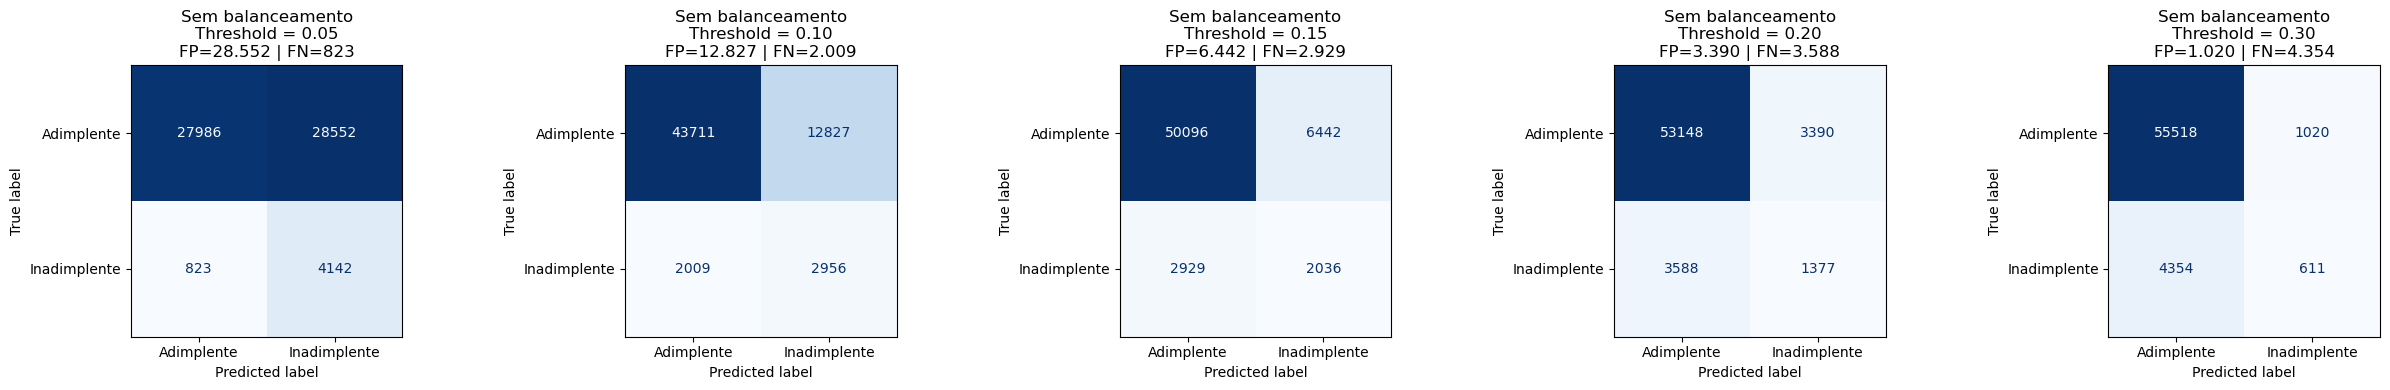

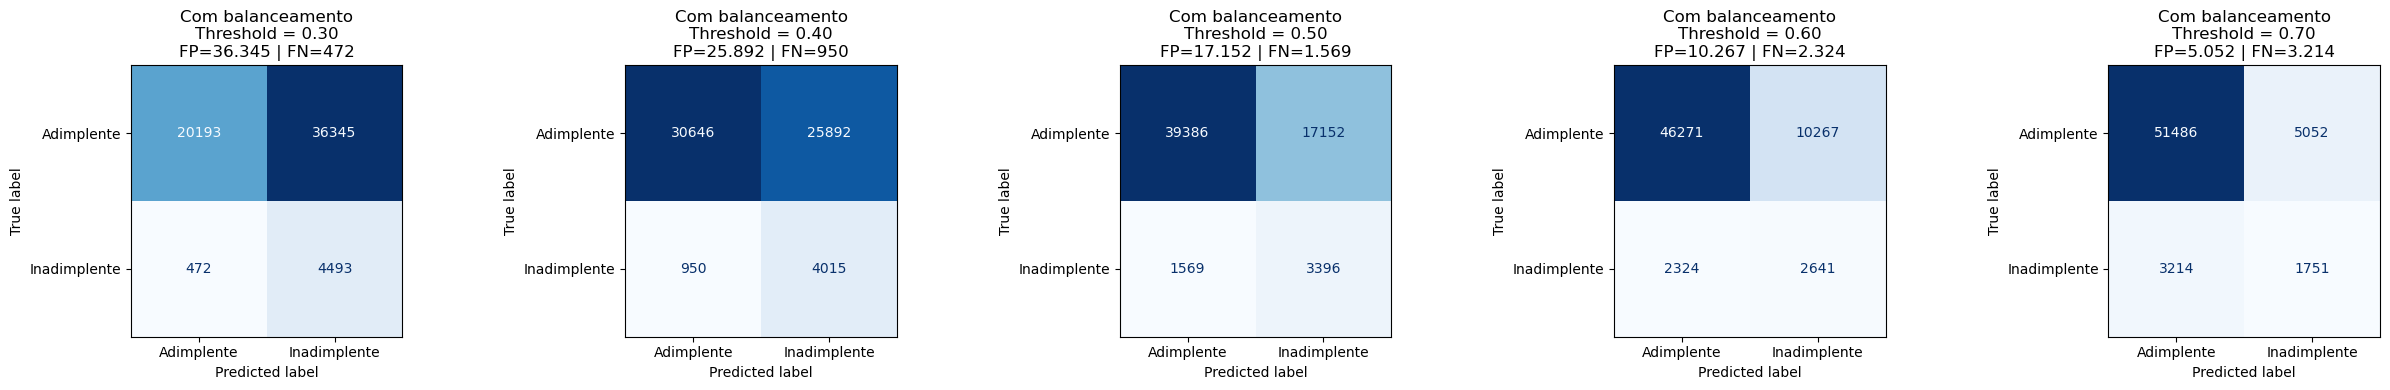

In [16]:
thresholds_sem_balanceamento = [0.05, 0.10, 0.15, 0.20, 0.30]

plot_confusion_by_thresholds(
    y_test,
    balance_probabilities["sem_balanceamento"],
    "Sem balanceamento",
    thresholds_sem_balanceamento
)

thresholds_com_balanceamento = [0.30, 0.40, 0.50, 0.60, 0.70]
plot_confusion_by_thresholds(
    y_test,
    balance_probabilities["com_balanceamento"],
    "Com balanceamento",
    thresholds_com_balanceamento
)

In [17]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

In [18]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

undersampling_pipeline = ImbPipeline([
    ("undersampler", RandomUnderSampler(random_state=42)),
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        solver="newton-cholesky",
        max_iter=100,
        random_state=42,
        class_weight=None,
    )),
])

param_grid_undersampling = {
    "classifier__C": [0.01, 0.1, 1.0, 10.0, 100.0],
}

grid_undersampling = GridSearchCV(
    estimator=undersampling_pipeline,
    param_grid=param_grid_undersampling,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
)

grid_undersampling.fit(X_train, y_train)

y_probability_undersampling = grid_undersampling.best_estimator_.predict_proba(X_test)[:, 1]
y_pred_undersampling = (y_probability_undersampling >= 0.50).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_undersampling).ravel()

undersampling_result = {
    "experimento": "undersampling",
    "class_weight": None,
    "best_C": grid_undersampling.best_params_["classifier__C"],
    "roc_auc": roc_auc_score(y_test, y_probability_undersampling),
    "average_precision": average_precision_score(y_test, y_probability_undersampling),
    "precision": precision_score(y_test, y_pred_undersampling, zero_division=0),
    "recall": recall_score(y_test, y_pred_undersampling),
    "f1": f1_score(y_test, y_pred_undersampling),
    "tn": tn,
    "fp": fp,
    "fn": fn,
    "tp": tp,
}

pd.DataFrame([undersampling_result])

,experimento,class_weight,best_C,roc_auc,average_precision,precision,recall,f1,tn,fp,fn,tp
0,undersampling,None,0.01,0.753551,0.238288,0.165335,0.683585,0.266269,39404,17134,1571,3394


In [19]:
df_balance_results = pd.concat([
    df_balance_results,
    pd.DataFrame([undersampling_result])
], ignore_index=True)

df_balance_results

,experimento,class_weight,best_C,roc_auc,average_precision,precision,recall,f1,tn,fp,fn,tp
0,sem_balanceamento,None,0.10,0.753829,0.239983,0.604027,0.018127,0.035197,56479,59,4875,90
1,com_balanceamento,balanced,0.01,0.754075,0.238204,0.165272,0.683988,0.266217,39386,17152,1569,3396
2,undersampling,None,0.01,0.753551,0.238288,0.165335,0.683585,0.266269,39404,17134,1571,3394


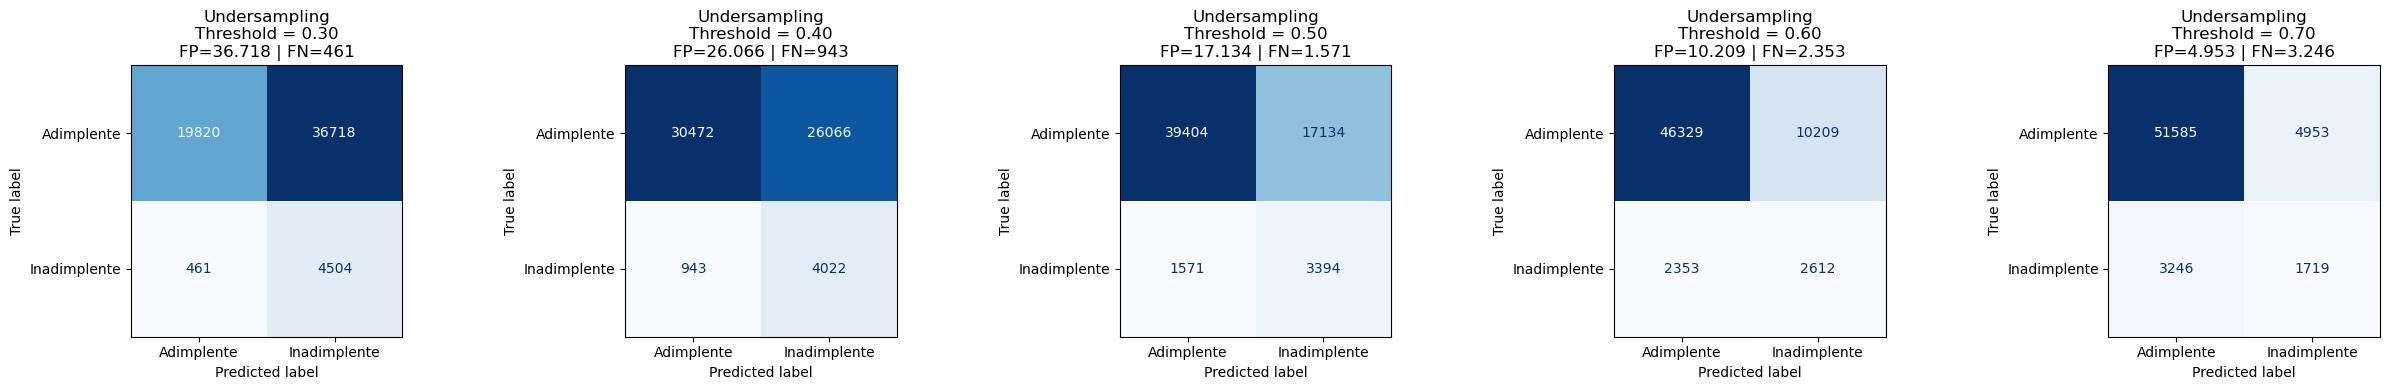

In [20]:
plot_confusion_by_thresholds(
    y_test,
    y_probability_undersampling,
    "Undersampling",
    [0.30, 0.40, 0.50, 0.60, 0.70]
)

Testando diferentes rates de undersampling

In [21]:
# ============================================================
# Treina um modelo por sampling_strategy e avalia thresholds
# ============================================================

sampling_strategies = [0.10, 0.15, 0.20, 0.30, 0.50, 0.75, 1.0]
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

undersampling_models_by_rate = {}
undersampling_probabilities_by_rate = {}
undersampling_results_by_rate = []

for sampling_strategy in sampling_strategies:
    pipeline = ImbPipeline([
        ("undersampler", RandomUnderSampler(
            sampling_strategy=sampling_strategy,
            random_state=42,
        )),
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            solver="newton-cholesky",
            max_iter=100,
            random_state=42,
            class_weight=None,
        )),
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid={"classifier__C": [0.01, 0.1, 1.0, 10.0, 100.0]},
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=True,
    )

    grid.fit(X_train, y_train)

    y_probability_rate = grid.best_estimator_.predict_proba(X_test)[:, 1]

    undersampling_models_by_rate[sampling_strategy] = grid.best_estimator_
    undersampling_probabilities_by_rate[sampling_strategy] = y_probability_rate

    for threshold in thresholds:
        y_pred_rate = (y_probability_rate >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rate).ravel()

        undersampling_results_by_rate.append({
            "sampling_strategy": sampling_strategy,
            "best_C": grid.best_params_["classifier__C"],
            "cv_roc_auc_mean": grid.best_score_,
            "threshold": threshold,
            "roc_auc": roc_auc_score(y_test, y_probability_rate),
            "average_precision": average_precision_score(y_test, y_probability_rate),
            "precision": precision_score(y_test, y_pred_rate, zero_division=0),
            "recall": recall_score(y_test, y_pred_rate),
            "f1": f1_score(y_test, y_pred_rate),
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
        })

df_undersampling_by_rate = pd.DataFrame(undersampling_results_by_rate)
df_undersampling_by_rate.sort_values(["sampling_strategy", "threshold"])

,sampling_strategy,best_C,cv_roc_auc_mean,threshold,roc_auc,average_precision,precision,recall,f1,tn,fp,fn,tp
0,0.10,0.10,0.752658,0.3,0.753776,0.239957,0.356301,0.158308,0.219216,55118,1420,4179,786
1,0.10,0.10,0.752658,0.4,0.753776,0.239957,0.440587,0.066465,0.115506,56119,419,4635,330
2,0.10,0.10,0.752658,0.5,0.753776,0.239957,0.563319,0.025982,0.049673,56438,100,4836,129
3,0.10,0.10,0.752658,0.6,0.753776,0.239957,0.677966,0.008056,0.015924,56519,19,4925,40
4,0.10,0.10,0.752658,0.7,0.753776,0.239957,0.538462,0.001410,0.002812,56532,6,4958,7
5,0.15,0.10,0.752724,0.3,0.753809,0.239714,0.288585,0.280564,0.284518,53104,3434,3572,1393
6,0.15,0.10,0.752724,0.4,0.753809,0.239714,0.362853,0.152669,0.214914,55207,1331,4207,758
7,0.15,0.10,0.752724,0.5,0.753809,0.239714,0.438070,0.067674,0.117237,56107,431,4629,336
8,0.15,0.10,0.752724,0.6,0.753809,0.239714,0.554167,0.026788,0.051105,56431,107,4832,133
9,0.15,0.10,0.752724,0.7,0.753809,0.239714,0.672727,0.007452,0.014741,56520,18,4928,37


## 6. Variáveis mais influentes

Quando o melhor modelo é linear, os coeficientes indicam associação com a pontuação de inadimplência. Quando é baseado em árvore, usamos a importância das variáveis do próprio modelo. Em ambos os casos, interpretabilidade não significa causalidade.

In [22]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
classifier = model.named_steps["classifier"]

if hasattr(classifier, "coef_"):
    importance = pd.DataFrame({
        "feature": feature_names,
        "importance": classifier.coef_[0],
        "absolute_importance": np.abs(classifier.coef_[0]),
    }).sort_values("absolute_importance", ascending=False)
elif hasattr(classifier, "feature_importances_"):
    importance = pd.DataFrame({
        "feature": feature_names,
        "importance": classifier.feature_importances_,
        "absolute_importance": classifier.feature_importances_,
    }).sort_values("absolute_importance", ascending=False)
else:
    importance = pd.DataFrame(columns=["feature", "importance", "absolute_importance"])

In [23]:
display(importance.head(50))

,feature,importance,absolute_importance
106,categorical__name_income_type_Pensioner,-1.368867,1.368867
109,categorical__name_education_type_Academic degree,-1.211724,1.211724
108,categorical__name_income_type_Working,0.693978,0.693978
107,categorical__name_income_type_State servant,0.621642,0.621642
104,categorical__name_income_type_Commercial assoc...,0.617939,0.617939
100,categorical__organization_type_Transport: type 3,0.590357,0.590357
103,categorical__organization_type_XNA,0.570928,0.570928
36,binary__days_employed_anom_1,0.570928,0.570928
35,binary__days_employed_anom_0,-0.570928,0.570928
105,categorical__name_income_type_Other_low_freq,-0.564692,0.564692


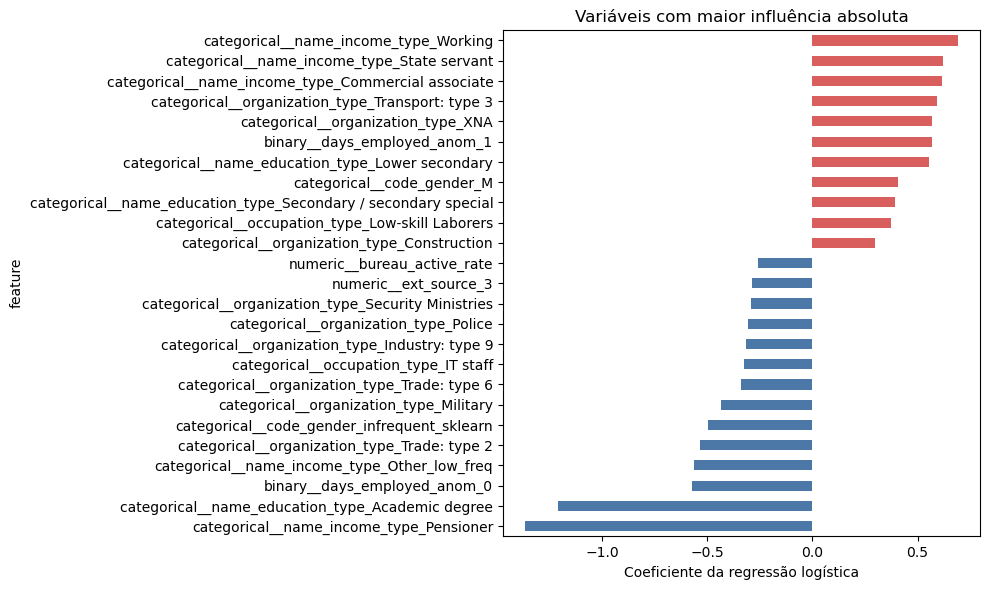

In [24]:
top = importance.head(25).sort_values('importance')
colors = np.where(top['importance'] >= 0, '#d95f5f', '#4c78a8')
top.plot.barh(x='feature', y='importance', color=colors, legend=False, figsize=(10, 6))
plt.title('Variáveis com maior influência absoluta')
plt.xlabel('Coeficiente da regressão logística')
plt.tight_layout(); plt.show()

In [25]:
df_model.columns

Index(['sk_id_curr', 'target', 'ext_source_2', 'ext_source_mean',
       'ext_source_1', 'ext_source_3', 'region_rating_client_w_city',
       'days_last_phone_change', 'days_id_publish', 'days_registration',
       'reg_city_not_work_city', 'reg_city_not_live_city',
       'live_city_not_work_city', 'has_car', 'own_car_age',
       'def_60_cnt_social_circle', 'amt_req_credit_bureau_year',
       'cnt_children', 'cnt_fam_members', 'amt_income_total', 'amt_credit',
       'amt_annuity', 'occupation_type', 'organization_type',
       'name_income_type', 'name_education_type', 'code_gender', 'age',
       'years_employed', 'days_employed_anom', 'fe_credit_income_percent',
       'fe_annuity_income_percent', 'prev_refused_rate', 'has_prev_app',
       'bureau_avg_days_credit', 'bureau_last_days_credit',
       'bureau_active_rate', 'bureau_active_count', 'bureau_closed_rate',
       'bureau_debt_credit_ratio', 'bureau_overdue_count',
       'inst_late_payment_rate', 'inst_underpayment_rate

In [26]:
print(df_model["days_employed_anom"].head())
print(df_model.info())

0    0
1    0
2    0
3    0
4    0
Name: days_employed_anom, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 45 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   sk_id_curr                   307511 non-null  int64  
 1   target                       307511 non-null  int64  
 2   ext_source_2                 307511 non-null  float64
 3   ext_source_mean              307511 non-null  float64
 4   ext_source_1                 307511 non-null  float64
 5   ext_source_3                 307511 non-null  float64
 6   region_rating_client_w_city  307511 non-null  int64  
 7   days_last_phone_change       307511 non-null  float64
 8   days_id_publish              307511 non-null  int64  
 9   days_registration            307511 non-null  float64
 10  reg_city_not_work_city       307511 non-null  int64  
 11  reg_city_not_live_city       307511 non-nul

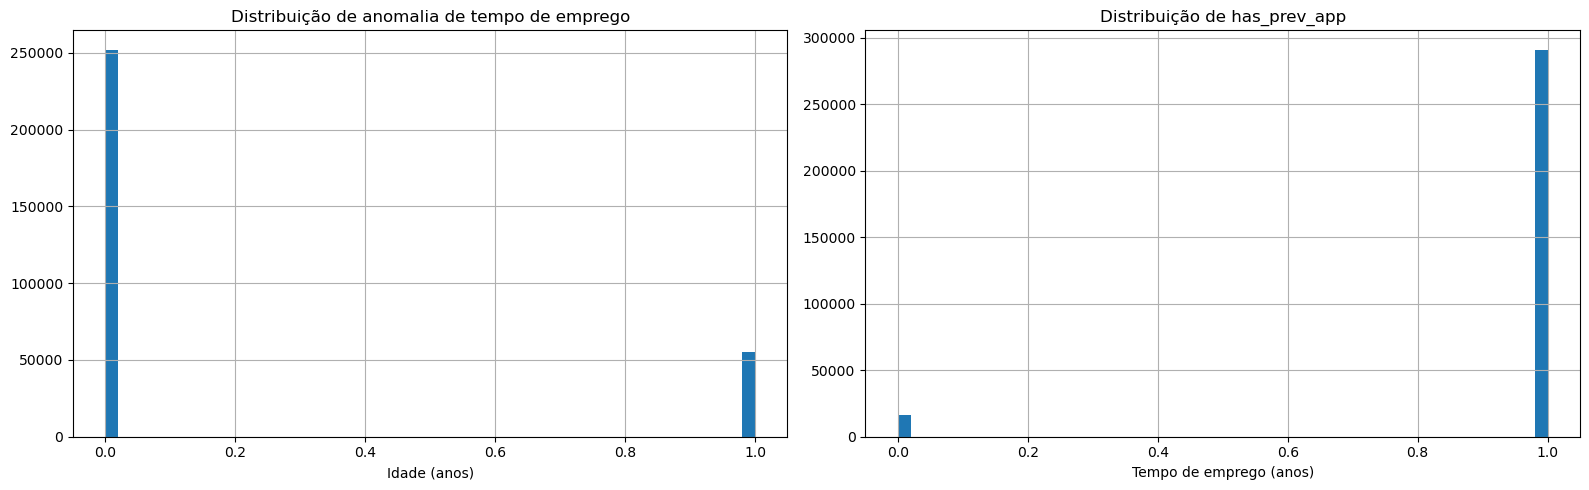

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
df_model["days_employed_anom"].hist(bins=50, ax=axes[0]); axes[0].set_title("Distribuição de anomalia de tempo de emprego"); axes[0].set_xlabel("Idade (anos)")
# df_model["years_employed"].hist(bins=50, ax=axes[1]); axes[1].set_title("Distribuição de tempo de emprego"); axes[1].set_xlabel("Tempo de emprego (anos)")
df_model["has_prev_app"].hist(bins=50, ax=axes[1]); axes[1].set_title("Distribuição de has_prev_app"); axes[1].set_xlabel("Tempo de emprego (anos)")
plt.tight_layout(); plt.show()

## 7. Persistência do modelo

O artefato contém pré-processamento, classificador, limiar e metadados necessários para inferência.

In [28]:
ARTIFACT_DIR = ABT_PATH.parent.parent / "Model/artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = ARTIFACT_DIR / "logistic_regression_abt.pkl"
COMPARISON_PATH = ARTIFACT_DIR / "model_comparison.csv"

artifact = {
    "model": model,
    "model_name": best_model_name,
    "decision_threshold": DECISION_THRESHOLD,
    "input_features": X.columns.tolist(),
    "metrics": {
        "roc_auc": roc_auc,
        "accuracy": accuracy,
        "precision": precision_model,
        "average_precision": average_precision,
        "cv_roc_auc": comparison.iloc[0]["cv_roc_auc_mean"],
    },
    "model_comparison": comparison.to_dict(orient="records"),
    "cv_folds": CV_FOLDS,
}
with MODEL_PATH.open("wb") as file:
    pickle.dump(artifact, file)
comparison.to_csv(COMPARISON_PATH, index=False)
print(f"Modelo salvo em: {MODEL_PATH.resolve()}")

Modelo salvo em: /home/jovyan/Model/artifacts/logistic_regression_abt.pkl
